<a href="https://colab.research.google.com/github/ssleona67/Integracion-de-datos-y-prospectiva/blob/main/Regresion_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión lineal

In [5]:
import pandas as pd

df = pd.read_csv('/content/sample_data/Dataset_heating_cost.csv', encoding="latin1")
df.head()

,Casa,Costo de calefacción (USD),Temp externa media (ºF),Aislamiento del atico (pulgadas),Antiguedad del calentador (años),Garaje
0,1,250,35,3,6,0
1,2,360,29,4,10,1
2,3,165,36,7,3,0
3,4,43,60,6,9,0
4,5,92,65,5,6,0


## Exploración de los datos

In [6]:
df.shape

(20, 6)

In [7]:
df.isna().sum()

,0
Casa,0
Costo de calefacción (USD),0
Temp externa media (ºF),0
Aislamiento del atico (pulgadas),0
Antiguedad del calentador (años),0
Garaje,0


In [8]:
df.describe()

,Casa,Costo de calefacción (USD),Temp externa media (ºF),Aislamiento del atico (pulgadas),Antiguedad del calentador (años),Garaje
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,205.250000,37.200000,6.350000,7.000000,0.400000
std,5.91608,105.858831,17.410221,2.476734,3.340344,0.502625
min,1.00000,43.000000,7.000000,2.000000,1.000000,0.000000
25%,5.75000,113.500000,25.500000,5.000000,5.000000,0.000000
50%,10.50000,202.500000,35.500000,6.000000,6.500000,0.000000
75%,15.25000,276.500000,54.250000,8.000000,9.250000,1.000000
max,20.00000,400.000000,65.000000,12.000000,15.000000,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Casa                              20 non-null     int64
 1   Costo de calefacción (USD)        20 non-null     int64
 2   Temp externa media (ºF)           20 non-null     int64
 3   Aislamiento del atico (pulgadas)  20 non-null     int64
 4   Antiguedad del calentador (años)  20 non-null     int64
 5   Garaje                            20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [10]:
df.corr()

,Casa,Costo de calefacción (USD),Temp externa media (ºF),Aislamiento del atico (pulgadas),Antiguedad del calentador (años),Garaje
Casa,1.000000,-0.091814,0.007154,0.314298,0.018643,0.106199
Costo de calefacción (USD),-0.091814,1.000000,-0.811509,-0.257101,0.536728,0.741885
Temp externa media (ºF),0.007154,-0.811509,1.000000,-0.103016,-0.485988,-0.508825
Aislamiento del atico (pulgadas),0.314298,-0.257101,-0.103016,1.000000,0.063617,-0.160660
Antiguedad del calentador (años),0.018643,0.536728,-0.485988,0.063617,1.000000,0.407526
Garaje,0.106199,0.741885,-0.508825,-0.160660,0.407526,1.000000


Visualmente no es muy fácil de interpretar la matriz de correlación en este formato. Es más fácil de interpretar a partir de un mapa de calor.

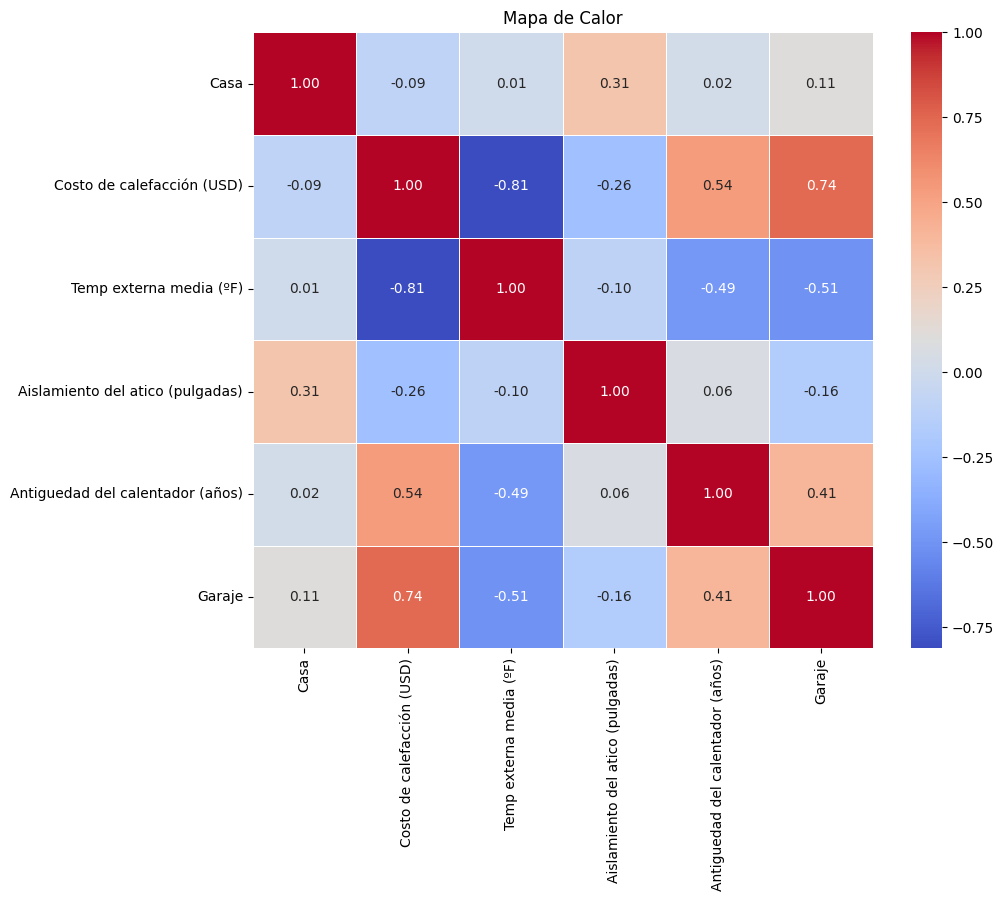

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor')
plt.show()

La variable "Casa" no hace parte de las variables a analizar, por ello no debería hacer parte de la matriz de correlación, ni del modelo de regresión, por ello deberíamos eliminarla.

In [12]:
df = df.drop(columns=['Casa'])
df.head()

,Costo de calefacción (USD),Temp externa media (ºF),Aislamiento del atico (pulgadas),Antiguedad del calentador (años),Garaje
0,250,35,3,6,0
1,360,29,4,10,1
2,165,36,7,3,0
3,43,60,6,9,0
4,92,65,5,6,0


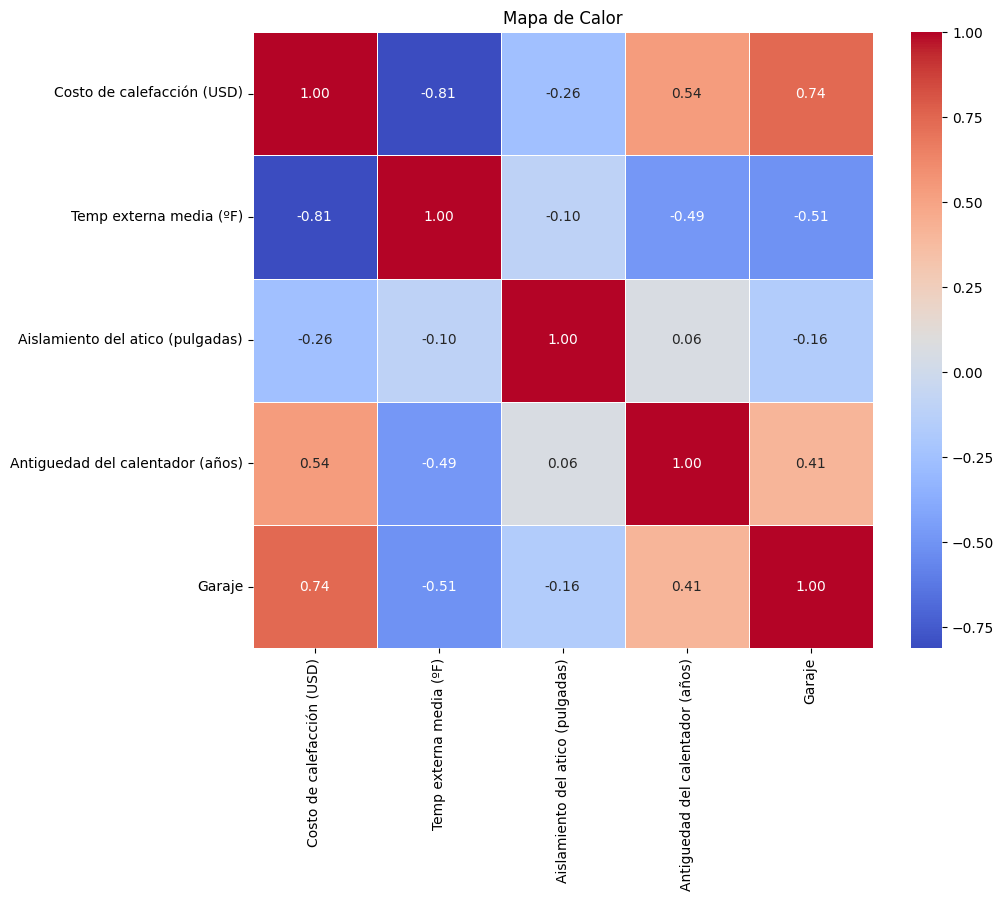

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor')
plt.show()

## Modelo de regresión lineal simple

$$\hat{Y}=a+bX$$

Donde:

**$\hat{Y}$**: predicción de Y  
**Y**: variable dependiente (que queremos predecir)  
**X**: variable(s) independiente(s) (predictores)  
**a**: intercepto (valor de Y cuando X = 0)  
**b**: pendiente (cuánto cambia Y por cada unidad de X)

In [ ]:
Y = df['Costo de calefacción (USD)']
X = df['Temp externa media (ºF)']

In [ ]:
df.columns

Index(['Costo de calefacción (USD)', 'Temp externa media (ºF)',
       'Aislamiento del atico (pulgadas)', 'Antiguedad del calentador (años)',
       'Garaje'],
      dtype='object')

## Modelo de regresión lineal solo con la variable `temperatura externa media (ºF)`

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Para usar las variables de la regresión, estas deben ser tipo array
X = np.array(X).reshape(-1, 1)
Y = np.array(Y).reshape(-1, 1)

# Modelo de regresión
modelo = LinearRegression()
modelo.fit(X, Y)

# Ver coeficientes
print("Intercepto (a):", modelo.intercept_)
print("Pendiente (b):", modelo.coef_)

Intercepto (a): [388.80195166]
Pendiente (b): [[-4.93419225]]


Por lo tanto, la ecuación de la regresión sería:

$$\hat{Y}=388.8 + -4.93 * X$$

Teniendo en cuenta que Y es el costo de la calefacción y X es la temperatura exterior en ºF. Si se tiene para la casa 1, una temperatura de 35 ºF, el costo de calefacción predicho es de:

$$\hat{Y}=388.8 + -4.93 * 35$$
$$\hat{Y}=216.10$$

Teniendo en cuenta que el valor real fue de 250 dolares, se tuvo un error de

$$Error=Y− \hat{Y}$$
$$Error=250− 216.10= 33.90$$

Lo que busca la regresión es minimizar la sumatoria de los errores de todas las observaciones

In [ ]:
import statsmodels.api as sm

# Intercepto
X_const = sm.add_constant(X)

# Modelo de regresión
modelo_sm = sm.OLS(Y, X_const).fit()

# Imprimir el resumen del modelo (incluye la ecuación y ANOVA)
print(modelo_sm.summary())

# Obtener y mostrar los residuales
residuales = modelo_sm.resid
print("\nResiduales:")
print(residuales)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     34.72
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           1.41e-05
Time:                        04:24:42   Log-Likelihood:                -110.36
No. Observations:                  20   AIC:                             224.7
Df Residuals:                      18   BIC:                             226.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        388.8020     34.241     11.355      0.0

**Interpretación de los Resultados de la Regresión OLS**

 **R-squared (R²)**: Este valor (0.659) indica que aproximadamente el 65.9% de la variabilidad en el costo de la calefacción puede ser explicada por la temperatura externa media. Un valor más alto significa un mejor ajuste del modelo.

 **Adj. R-squared (R² ajustado)**: Similar al R-squared, pero ajustado por el número de predictores en el modelo. Es útil para comparar modelos con diferente número de variables.

 **F-statistic**: Esta es una prueba de la significancia general del modelo. Un valor alto (34.72) con una probabilidad baja (Prob (F-statistic) de 1.41e-05) sugiere que el modelo es estadísticamente significativo.

 **coef (Coeficientes):**
     const (Intercepto): El valor de 388.8020 es el costo de calefacción predicho cuando la temperatura externa es 0°F.
     x1 (Pendiente): El valor de -4.9342 indica que por cada grado Fahrenheit que aumenta la temperatura externa, el costo de la calefacción disminuye en aproximadamente 4.93 USD.

 **P>|t| (Valor p):** Estos valores prueban la significancia de cada coeficiente. Un valor p bajo (generalmente < 0.05) indica que el coeficiente es estadísticamente significativo. En tu caso, tanto el intercepto como el coeficiente de la temperatura son significativos.

 **[0.025 0.975] (Intervalo de Confianza)**: Este es el rango en el que se espera que se encuentre el verdadero valor del coeficiente con un 95% de confianza.


**Grafico de los residuales**

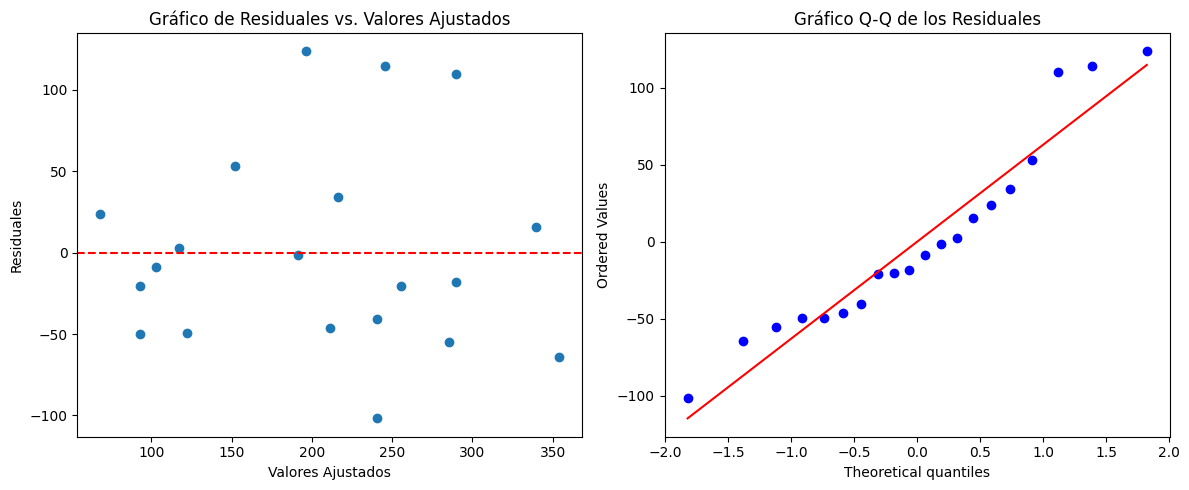

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Gráfico de residuales vs. valores ajustados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(modelo_sm.fittedvalues, residuales)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuales')
plt.title('Gráfico de Residuales vs. Valores Ajustados')

# Gráfico Q-Q de los residuales
plt.subplot(1, 2, 2)
stats.probplot(residuales, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de los Residuales')

plt.tight_layout()
plt.show()

## Modelo de regresión lineal múltiple con todas las variables

In [ ]:
Y1 = df['Costo de calefacción (USD)']
X1 = df[['Temp externa media (ºF)','Aislamiento del atico (pulgadas)', 'Antiguedad del calentador (años)', 'Garaje']]

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Para usar las variables de la regresión, estas deben ser tipo array
X = np.array(X1)
Y = np.array(Y1).reshape(-1, 1)

# Modelo de regresión
modelo = LinearRegression()
modelo.fit(X, Y)

# Ver coeficientes
print("Intercepto (a):", modelo.intercept_)
print("Pendiente (b):", modelo.coef_)

Intercepto (a): [361.74611722]
Pendiente (b): [[ -3.70026343 -11.66339038   3.80222121  71.50165717]]


**¿Cómo funciona la regresión?**

La idea es minimizar la suma de los errores al cuadrado, es decir:
$$Error=Y− \hat{Y}$$

Queremos minimizar:

$$Min ∑(Yi−\hat{Y})^2$$


Ahora veremos como calcular la ecuación de la regresión

$$\hat{Y}=a+bX$$

El coeficiente de la variable independiente se calcula de la siguiente manera:

$$b=\frac{∑(Xi​−\bar{X})(Yi​−\bar{Y})}{∑(Xi​−\bar{X})^2}$$​



El intercepto se calcula de la siguiente manera

$$a=\bar{Y}−b\bar{X}$$

# Metricas de desempeño

In [ ]:
y_real= df['Costo de calefacción (USD)']
y_pred= modelo.predict(X)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# y_real: valores verdaderos
# y_pred: valores predichos por el modelo

r2 = r2_score(y_real, y_pred)
mse = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mse)  # raíz del MSE
mae = mean_absolute_error(y_real, y_pred)

print("R^2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R^2: 0.8802792924330408
RMSE: 35.70043714168622
MAE: 29.725597949458432


# Ejercicio práctico
Ahora queremos mejorar el modelo, por lo tanto, vamos a probar con las otras variables independientes disponibles en el dataset, hasta obtener el mejor modelo.

## Modelo con 'aislamiento del atico (pulgadas)'


In [ ]:
X_aislamiento = df['Aislamiento del atico (pulgadas)']
X_aislamiento_const = sm.add_constant(X_aislamiento)
modelo_aislamiento = sm.OLS(Y, X_aislamiento_const).fit()
print(modelo_aislamiento.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     1.274
Date:                Thu, 30 Jul 2026   Prob (F-statistic):              0.274
Time:                        04:25:27   Log-Likelihood:                -120.42
No. Observations:                  20   AIC:                             244.8
Df Residuals:                      18   BIC:                             246.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

## Modelo con 'antigüedad del calentador (años)'



In [ ]:
X_antiguedad = df['Antiguedad del calentador (años)']
X_antiguedad_const = sm.add_constant(X_antiguedad)
modelo_antiguedad = sm.OLS(Y, X_antiguedad_const).fit()
print(modelo_antiguedad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.249
Method:                 Least Squares   F-statistic:                     7.284
Date:                Thu, 30 Jul 2026   Prob (F-statistic):             0.0147
Time:                        04:25:33   Log-Likelihood:                -117.71
No. Observations:                  20   AIC:                             239.4
Df Residuals:                      18   BIC:                             241.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

## Modelo con 'garaje'



In [ ]:
X_garaje = df['Garaje']
X_garaje_const = sm.add_constant(X_garaje)
modelo_garaje = sm.OLS(Y, X_garaje_const).fit()
print(modelo_garaje.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     22.04
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           0.000181
Time:                        04:25:37   Log-Likelihood:                -113.11
No. Observations:                  20   AIC:                             230.2
Df Residuals:                      18   BIC:                             232.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        142.7500     21.052      6.781      0.0

## Modelo de regresión múltiple



Modelo con todas las variables predictoras



In [ ]:
X_multiple = df[['Temp externa media (ºF)', 'Aislamiento del atico (pulgadas)', 'Garaje']]
X_multiple_const = sm.add_constant(X_multiple)
modelo_multiple = sm.OLS(Y, X_multiple_const).fit()
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     35.64
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           2.59e-07
Time:                        04:25:42   Log-Likelihood:                -100.72
No. Observations:                  20   AIC:                             209.4
Df Residuals:                      16   BIC:                             213.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

## Comparar los modelo




In [ ]:
# Create a dictionary to store the results
results = {
    'Model': ['Aislamiento', 'Antigüedad', 'Garaje', 'Múltiple'],
    'R-squared': [
        modelo_aislamiento.rsquared,
        modelo_antiguedad.rsquared,
        modelo_garaje.rsquared,
        modelo_multiple.rsquared
    ],
    'Adjusted R-squared': [
        modelo_aislamiento.rsquared_adj,
        modelo_antiguedad.rsquared_adj,
        modelo_garaje.rsquared_adj,
        modelo_multiple.rsquared_adj
    ]
}

# Create a DataFrame from the dictionary
comparison_df = pd.DataFrame(results)

# Print the comparison DataFrame
print("Comparación de Modelos:")
display(comparison_df)

# Identify the best model
best_model_r2 = comparison_df.loc[comparison_df['R-squared'].idxmax()]
best_model_adj_r2 = comparison_df.loc[comparison_df['Adjusted R-squared'].idxmax()]

print(f"\nEl mejor modelo según R-cuadrado es: {best_model_r2['Model']} (R² = {best_model_r2['R-squared']:.3f})")
print(f"El mejor modelo según R-cuadrado ajustado es: {best_model_adj_r2['Model']} (R² ajustado = {best_model_adj_r2['Adjusted R-squared']:.3f})")


Comparación de Modelos:


,Model,R-squared,Adjusted R-squared
0,Aislamiento,0.066101,0.014218
1,Antigüedad,0.288076,0.248525
2,Garaje,0.550394,0.525416
3,Múltiple,0.869838,0.845433



El mejor modelo según R-cuadrado es: Múltiple (R² = 0.870)
El mejor modelo según R-cuadrado ajustado es: Múltiple (R² ajustado = 0.845)


## Resultados del mejor modelo



In [ ]:
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     35.64
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           2.59e-07
Time:                        04:26:06   Log-Likelihood:                -100.72
No. Observations:                  20   AIC:                             209.4
Df Residuals:                      16   BIC:                             213.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

# Presentación de resultados

1. ¿Cuál variable predictora es la mejor para un modelo de regresión lineal simple?

Basado en los valores de R-cuadrado, ‘Garaje’ (R² = 0.550) es el mejor predictor individual entre los modelos de regresión lineal simple, ya que explica el 55% de la variabilidad en la factura del gas.

2. ¿Cuál es el mejor modelo general para predecir la factura de la calefacción?

El modelo de regresión lineal múltiple, que incluye todas las variables predictoras, es el mejor modelo general. Tiene un R-cuadrado de 0.880 y un R-cuadrado ajustado de 0.848, lo que indica que explica aproximadamente el 88% de la variabilidad en la factura del gas.

3. ¿Cuáles son los resultados del mejor modelo?

El modelo de regresión lineal múltiple muestra que:

- Por cada grado adicional en la temperatura externa promedio, se predice que la factura del gas disminuye en $3.70.

- Por cada pulgada adicional de aislamiento en el ático, se predice que la factura de la calefacción disminuye en $11.66.

- Tener un garaje se asocia con un aumento de aproximadamente $71.50 en la factura dela calefacción.

La antigüedad de la calefacción no fue un predictor estadísticamente significativo en este modelo.


## Hallazgos clave del análisis de datos

El modelo de regresión lineal múltiple supera significativamente a todos los modelos de regresión lineal simple, con un R-cuadrado ajustado de 0.848 frente al mejor modelo simple (‘Garaje’) que tenía un R-cuadrado ajustado de 0.525.

En el modelo múltiple, las variables ‘Temp externa media (ºF)’, ‘Aislamiento del ático (pulgadas)’ y ‘Garaje’ fueron todas predictoras estadísticamente significativas de la factura del gas, con valores p de 0.000, 0.010 y 0.007, respectivamente.

La ‘Antigüedad del calentador (años)’ fue significativa en su modelo de regresión simple (valor p = 0.015), pero se volvió estadísticamente no significativa (valor p = 0.271) en el modelo múltiple, lo que sugiere que su efecto podría estar siendo capturado o correlacionado con otras variables.

La temperatura externa promedio y el aislamiento del ático tienen una correlación negativa con la factura del gas, mientras que tener un garaje tiene una correlación positiva.

## Pasos a seguir

- Dado que la variable ‘Antigüedad del calentador’ no es significativa en presencia de otras variables, se podría construir un modelo más parcimonioso eliminándola, para ver si se mantiene el poder predictivo del modelo.

- Investigar las razones detrás de la correlación positiva entre tener un garaje y una factura de la calefacción. Esto podría deberse a factores como un mal aislamiento del garaje o que el garaje sea un espacio calefaccionado, lo cual podría ser una nueva variable a considerar.



# Problemas que se pueden presentar en la regresión lineal multivariante

# Multicolinealidad
- Es cuando dos o más variables independientes están fuertemente correlacionadas entre sí.

## Cómo detectarla:
- Calculando el VIF (Variance Inflation Factor): valores > 5 o 10 indican problemas.

## Soluciones:
- Eliminar variables redundantes, combinar variables, usar regresión ridge o LASSO.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Definir las variables independientes
X_vif = df[['Temp externa media (ºF)', 'Aislamiento del atico (pulgadas)', 'Antiguedad del calentador (años)', 'Garaje']]

# Calcular el VIF para cada variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data)

# Heterocedasticidad

- Es cuando la varianza de los errores no es constante a lo largo de los valores de X.
- Los errores estándar no son confiables → los tests estadísticos (como el p-valor) pueden ser incorrectos.

## Cómo detectarlo:
- Gráfico de residuos vs. predicciones: si hay forma de "cono", hay heterocedasticidad.
- Test de Breusch-Pagan.

##Soluciones:
- Transformar variables (log, sqrt), usar regresión robusta.

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Gráfico de residuales vs. valores ajustados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(modelo_multiple.fittedvalues, residuales)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuales')
plt.title('Gráfico de Residuales vs. Valores Ajustados')

# Gráfico Q-Q de los residuales
plt.subplot(1, 2, 2)
stats.probplot(residuales, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de los Residuales')

plt.tight_layout()
plt.show()